In [ ]:
!gdown 1F-SgoQ78t9GN6-B9nCM_7P82SYXrH1NY # lagenda_clean_noface
!unzip lagenda_clean_noface

In [ ]:
!gdown 1yJfqXO3dIkcIXwLNDvAWauPvpg--Z6sC

Downloading...
From: https://drive.google.com/uc?id=1yJfqXO3dIkcIXwLNDvAWauPvpg--Z6sC
To: /content/lagenda_clean_annotation.csv
100% 1.63M/1.63M [00:00<00:00, 13.2MB/s]


In [ ]:
import pandas as pd

df = pd.read_csv('lagenda_clean_annotation.csv')

idades_por_imagem = (
    df.groupby('img_name')['age']
      .apply(lambda x: list(x) if (x != -1).all() else None)
      .reset_index()
).sort_values('img_name')

print(f"{len(idades_por_imagem)} imagens têm todas as idades conhecidas.")
display(idades_por_imagem)

20182 imagens têm todas as idades conhecidas.


,img_name,age
0,lag_benchmark/0000339d0372e7e6.jpg,[27]
1,lag_benchmark/0004350a376865f5.jpg,"[5, 6]"
2,lag_benchmark/00059fa95ee95e65.jpg,[79]
3,lag_benchmark/0007473cdbe8c18d.jpg,[6]
4,lag_benchmark/000851174d48d3d9.jpg,[4]
...,...,...
20177,lag_benchmark/fff74322fa07c7c1.jpg,[41]
20178,lag_benchmark/fff934bd1ff95af5.jpg,[76]
20179,lag_benchmark/fffb40d02f510b35.jpg,[18]
20180,lag_benchmark/ffff1ad4bf685255.jpg,[22]


In [ ]:
real = {'real_prompt1': [], 'real_prompt2': [],
        'real_prompt3': [], 'real_prompt4': []}

for idade in idades_por_imagem['age']:
    jovem = min(idade)
    real['real_prompt1'] += [1 if jovem <= 13 else 0]
    real['real_prompt2'] += [1 if jovem <= 17 else 0]
    real['real_prompt4'] += [jovem]

    if jovem <= 13:
        valor = 0
    elif jovem <= 17:
        valor = 1
    elif jovem <= 59:
        valor = 2
    else:
        valor = 3

    real['real_prompt3'] += [valor]

In [ ]:
pred_prompt1 = pd.read_csv(f'resultados_qwen2.5_prompt1_noface.csv').sort_values('img_name')
pred_prompt2 = pd.read_csv(f'resultados_qwen2.5_prompt2_noface.csv').sort_values('img_name')
pred_prompt3 = pd.read_csv(f'resultados_qwen2.5_prompt3_noface.csv').sort_values('img_name')
pred_prompt4 = pd.read_csv(f'resultados_internvl3_prompt4_json_noface.csv').sort_values('img_name')

In [ ]:
resultadosLlava = pd.DataFrame()
resultadosLlava['img_name'] = idades_por_imagem['img_name']

resultadosLlava['pred_prompt1'] = pred_prompt1['resposta_modelo']
resultadosLlava['real_prompt1'] = real['real_prompt1']

resultadosLlava['pred_prompt2'] = pred_prompt2['resposta_modelo']
resultadosLlava['real_prompt2'] = real['real_prompt2']

resultadosLlava['pred_prompt3'] = pred_prompt3['resposta_modelo']
resultadosLlava['real_prompt3'] = real['real_prompt3']

resultadosLlava['pred_prompt4'] = pred_prompt4['resposta_modelo']
resultadosLlava['real_prompt4'] = real['real_prompt4']
resultadosLlava

,img_name,pred_prompt1,real_prompt1,pred_prompt2,real_prompt2,pred_prompt3,real_prompt3,pred_prompt4,real_prompt4
0,lag_benchmark/0000339d0372e7e6.jpg,0.0,0,0.0,0,adulto,2,20,27
1,lag_benchmark/0004350a376865f5.jpg,1.0,1,1.0,1,criança,0,6,5
2,lag_benchmark/00059fa95ee95e65.jpg,0.0,0,0.0,0,Não é possível determinar,3,18,79
3,lag_benchmark/0007473cdbe8c18d.jpg,1.0,1,1.0,1,criança,0,10,6
4,lag_benchmark/000851174d48d3d9.jpg,1.0,1,1.0,1,criança,0,4,4
...,...,...,...,...,...,...,...,...,...
20177,lag_benchmark/fff74322fa07c7c1.jpg,0.0,0,0.0,0,adulto,2,30,41
20178,lag_benchmark/fff934bd1ff95af5.jpg,0.0,0,0.0,0,adulto,3,25,76
20179,lag_benchmark/fffb40d02f510b35.jpg,0.0,0,1.0,0,ado\n addCriterion\nadult,2,18,18
20180,lag_benchmark/ffff1ad4bf685255.jpg,0.0,0,0.0,0,adulto,2,25,22


- with face
```
p1: (np.float64(0.9464819114988899), 0.9397401902672136, 0.921018729560995)
p2: (np.float64(0.905008270915419), 0.907943211525752, 0.8644832028540284)
p3: (np.float64(0.7476596073187245), 0.8571735638005169, 0.7329303339609553)
p4:
MAE 0: 1.112959539946601
MAE 1: 2.5386029411764706
MAE 2: 11.69811320754717
MAE 3: 30.56519120746763
```

- no face
```
p1: (np.float64(0.9301649068589267), 0.9415924060464251, 0.9393023486274898)
p2: (np.float64(0.8959373014288883), 0.9015157671062642, 0.8802398176593004)
(np.float64(0.6184583753097845), 0.8020729228058433, 0.6197106332375384)
p4:
MAE 0: 2.2651468474019305
MAE 1: 2.738970588235294
MAE 2: 13.119584206848359
MAE 3: 39.42728093947606
```

In [ ]:
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score, precision_score,
    recall_score, mean_absolute_error,
    confusion_matrix
)

### metricas
rotulo = resultadosLlava['real_prompt1']
previsao = resultadosLlava['pred_prompt1']
balanced_accuracy_score(rotulo, previsao), precision_score(rotulo, previsao, average='weighted'), recall_score(rotulo, previsao, average='weighted')

(np.float64(0.9301649068589267), 0.9415924060464251, 0.9393023486274898)

In [ ]:
### metricas
rotulo = resultadosLlava['real_prompt2']
previsao = resultadosLlava['pred_prompt2']
balanced_accuracy_score(rotulo, previsao), precision_score(rotulo, previsao, average='weighted'), recall_score(rotulo, previsao, average='weighted')

(np.float64(0.8959373014288883), 0.9015157671062642, 0.8802398176593004)

In [ ]:
def clean_prompt3(value):
    value = value.lower()
    if 'addCriterion' in value: value = 'adolescente'
    elif 'não' in value: value = 'criança'
    elif 'cão' in value: value = 'criança'
    elif 'ado' in value: value = 'adolescente'
    return ['criança', 'adolescente', 'adulto', 'idoso'].index(value)
resultadosLlava['pred_prompt3'] = resultadosLlava['pred_prompt3'].apply(clean_prompt3)

rotulo = resultadosLlava['real_prompt3']
previsao = resultadosLlava['pred_prompt3']
balanced_accuracy_score(rotulo, previsao), precision_score(rotulo, previsao, average='weighted'), recall_score(rotulo, previsao, average='weighted')

(np.float64(0.6184583753097845), 0.8020729228058433, 0.6197106332375384)

In [ ]:
def clean_prompt4(value):
    try:
        value = int(value)
    except:
        value = 0
    return value
resultadosLlava['pred_prompt4'] = resultadosLlava['pred_prompt4'].apply(clean_prompt4)

for clas in range(4):
    rotulo = resultadosLlava[resultadosLlava['real_prompt3'] == clas]['real_prompt4']
    previsao = resultadosLlava[resultadosLlava['real_prompt3'] == clas]['pred_prompt4']

    print(f'MAE {clas}:', mean_absolute_error(rotulo, previsao))

MAE 0: 2.2651468474019305
MAE 1: 2.738970588235294
MAE 2: 13.119584206848359
MAE 3: 39.42728093947606


## Distribuição de idades

In [ ]:
# idades_por_imagem

real = {'real_prompt1': [], 'real_prompt2': [],
        'real_prompt3': [], 'real_prompt4': []}

for idade in idades_por_imagem['age']:
    real['real_prompt1'].append([])
    real['real_prompt2'].append([])
    real['real_prompt3'].append([])
    real['real_prompt4'].append([])

    for i in idade:
        real['real_prompt1'][-1].append(1 if i <= 13 else 0)
        real['real_prompt2'][-1].append(1 if i <= 17 else 0)
        real['real_prompt4'][-1].append(i)

        if i <= 13:
            valor = 0
        elif i <= 17:
            valor = 1
        elif i <= 59:
            valor = 2
        else:
            valor = 3

        real['real_prompt3'][-1].append(valor)

In [ ]:
resultadosLlava = pd.DataFrame()
resultadosLlava['img_name'] = idades_por_imagem['img_name']

resultadosLlava['pred_prompt1'] = pred_prompt1['resposta_modelo']
resultadosLlava['real_prompt1'] = real['real_prompt1']

resultadosLlava['pred_prompt2'] = pred_prompt2['resposta_modelo']
resultadosLlava['real_prompt2'] = real['real_prompt2']

resultadosLlava['pred_prompt3'] = pred_prompt3['resposta_modelo']
resultadosLlava['real_prompt3'] = real['real_prompt3']

resultadosLlava['pred_prompt4'] = pred_prompt4['resposta_modelo']
resultadosLlava['real_prompt4'] = real['real_prompt4']
resultadosLlava

,img_name,pred_prompt1,real_prompt1,pred_prompt2,real_prompt2,pred_prompt3,real_prompt3,pred_prompt4,real_prompt4
0,lag_benchmark/0000339d0372e7e6.jpg,0.0,[0],0.0,[0],adulto,[2],"{\n ""número de pessoas"": 1,\n ""pessoas"": [\n...",[27]
1,lag_benchmark/0004350a376865f5.jpg,1.0,"[1, 1]",1.0,"[1, 1]",criança,"[0, 0]","{\n ""número de pessoas"": 2,\n ""pessoas"": [\n...","[5, 6]"
2,lag_benchmark/00059fa95ee95e65.jpg,0.0,[0],0.0,[0],Não é possível determinar,[3],"{\n ""número de pessoas"": 1,\n ""pessoas"": [\n...",[79]
3,lag_benchmark/0007473cdbe8c18d.jpg,1.0,[1],1.0,[1],criança,[0],"{\n ""número de pessoas"": 1,\n ""pessoas"": [\n...",[6]
4,lag_benchmark/000851174d48d3d9.jpg,1.0,[1],1.0,[1],criança,[0],"{\n ""número de pessoas"": 1,\n ""pessoas"": [\n...",[4]
...,...,...,...,...,...,...,...,...,...
20177,lag_benchmark/fff74322fa07c7c1.jpg,0.0,[0],0.0,[0],adulto,[2],"{\n ""número de pessoas"": 1,\n ""pessoas"": [\n...",[41]
20178,lag_benchmark/fff934bd1ff95af5.jpg,0.0,[0],0.0,[0],adulto,[3],"{\n ""número de pessoas"": 1,\n ""pessoas"": [\n...",[76]
20179,lag_benchmark/fffb40d02f510b35.jpg,0.0,[0],1.0,[0],ado\n addCriterion\nadult,[2],"{\n ""número de pessoas"": 1,\n ""pessoas"": [\n...",[18]
20180,lag_benchmark/ffff1ad4bf685255.jpg,0.0,[0],0.0,[0],adulto,[2],"{\n ""número de pessoas"": 1,\n ""pessoas"": [\n...",[22]


In [ ]:
np.unique(unicos)

array(['adult', 'adultd', 'adulte', 'adulto', 'adultul', 'adultut',
       'child', 'criança'], dtype='<U7')

In [ ]:
unicos = []
cont_except = [0]
def clean_json_prompt1(value):
    if value.startswith('```json'):
        value = value[7:-3]

    resposta = []

    try:
        data_dict = eval(value)
        chave = 'pessoas'
        key_categoria = 'categoria'
        categorias = ['criança', 'child']
        if 'people' in data_dict.keys():
            chave = 'people'
            key_categoria = 'category'

        for pessoa in data_dict[chave]:
            unicos.append(pessoa[key_categoria])
            resposta.append(1 if pessoa[key_categoria] in categorias else 0)

    except:
        cont_except[-1] += 1
        resposta = [1] * value.count('criança')
        resposta.extend([0] * value.count('adulto'))

    return resposta


resultadosLlava['pred_prompt1'] = resultadosLlava['pred_prompt1'].apply(clean_json_prompt1)
resultadosLlava['pred_prompt2'] = resultadosLlava['pred_prompt2'].apply(clean_json_prompt1)

In [ ]:
np.unique(unicos),cont_except

(array(['adoecente', 'adoeente', 'adoobente', 'adoodecent', 'adoodecente',
        'adooecente', 'adooeente', 'adoopecente', 'adoócente', 'adult',
        'adultd', 'adulto', 'child', 'criança', 'ido', 'idoso', 'infant',
        'infante'], dtype='<U11'),
 [42])

In [ ]:
unicos = []
cont_except = [0]

catlist = ['criança', 'adolescente', 'adulto', 'idoso']
def clean_json_prompt3(value):
    if value.startswith('```json'):
        value = value[7:-3]

    resposta = []

    try:
        data_dict = eval(value)
        chave = 'pessoas'
        key_categoria = 'categoria'

        if 'people' in data_dict.keys():
            chave = 'people'
            key_categoria = 'category'

        for pessoa in data_dict[chave]:
            cat = pessoa[key_categoria]
            unicos.append(pessoa[key_categoria])
            if cat.startswith('ado'):
                resposta.append(catlist.index('adolescente'))
            elif cat.startswith('adul'):
                resposta.append(catlist.index('adulto'))
            elif cat.startswith('ido'):
                resposta.append(catlist.index('idoso'))
            else: # child, criança, infant, infante
                resposta.append(catlist.index('criança'))

    except: # só deu exception em adolescente
        cont_except[-1] += 1
        resposta = [1] * value.count('ado')

    return resposta


resultadosLlava['pred_prompt3'] = resultadosLlava['pred_prompt3'].apply(clean_json_prompt3)


In [ ]:
import re
def clean_json_prompt4(value):
    if value.startswith('```json'):
        value = value[7:-3]

    resposta = []
    chave = 'pessoas'
    key_categoria = 'idade'
    if 'people' in value:
        chave = 'people'
        key_categoria = 'age'

    if '(' in value:
        value = re.sub(r'\d+\((\d+)\)', r'\1', value)

    try:
        data_dict = eval(value)
        for pessoa in data_dict[chave]:
            unicos.append(pessoa[key_categoria])
            resposta.append(int(pessoa[key_categoria]))

    except:
        pos = value.find(key_categoria)
        while pos != -1:
            try:
                val = value[pos:].split(':')[1].split()[0].split('}')[0].strip()
                resposta.append(int(val))
            except:
                pass
            pos = value.find(key_categoria, pos+1)
    return resposta


resultadosLlava['pred_prompt4'] = resultadosLlava['pred_prompt4'].apply(clean_json_prompt4)


In [ ]:
resultadosLlava['img_name'] = resultadosLlava['img_name'].apply(lambda x: f"images_noface/{x.split('/')[-1]}")
resultadosLlava

,img_name,pred_prompt1,real_prompt1,pred_prompt2,real_prompt2,pred_prompt3,real_prompt3,pred_prompt4,real_prompt4
0,images_noface/0000339d0372e7e6.jpg,0.0,[0],0.0,[0],adulto,[2],[25],[27]
1,images_noface/0004350a376865f5.jpg,1.0,"[1, 1]",1.0,"[1, 1]",criança,"[0, 0]","[5, 6]","[5, 6]"
2,images_noface/00059fa95ee95e65.jpg,0.0,[0],0.0,[0],Não é possível determinar,[3],[40],[79]
3,images_noface/0007473cdbe8c18d.jpg,1.0,[1],1.0,[1],criança,[0],[5],[6]
4,images_noface/000851174d48d3d9.jpg,1.0,[1],1.0,[1],criança,[0],[5],[4]
...,...,...,...,...,...,...,...,...,...
20177,images_noface/fff74322fa07c7c1.jpg,0.0,[0],0.0,[0],adulto,[2],[35],[41]
20178,images_noface/fff934bd1ff95af5.jpg,0.0,[0],0.0,[0],adulto,[3],[70],[76]
20179,images_noface/fffb40d02f510b35.jpg,0.0,[0],1.0,[0],ado\n addCriterion\nadult,[2],[20],[18]
20180,images_noface/ffff1ad4bf685255.jpg,0.0,[0],0.0,[0],adulto,[2],[25],[22]


In [ ]:
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score, precision_score,
    recall_score, mean_absolute_error,
    confusion_matrix
)
from sklearn.preprocessing import MultiLabelBinarizer

#1, 2, 3
for i in range(1, 4):
    mlb = MultiLabelBinarizer()
    y_true_bin = mlb.fit_transform(resultadosLlava[f'real_prompt{i}'])
    y_pred_bin = mlb.transform(resultadosLlava[f'pred_prompt{i}'])

    acc = accuracy_score(y_true_bin, y_pred_bin,)
    prec = precision_score(y_true_bin, y_pred_bin, average='weighted')
    rec = recall_score(y_true_bin, y_pred_bin, average='weighted')
    print(acc, prec, rec)

0.927410563868794 0.9378643199138404 0.9419592438006383
0.9156178773164205 0.9264844545823933 0.9318973553800108
0.0 0.0 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['\n', ' ', '!', '"', '*', ',', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', '[', ']', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'y', '{', '}', 'ç', 'ó', 'ú'] will be ignored
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from scipy.stats import wasserstein_distance
import numpy as np

for clas in range(4):
    val = []
    rotulo = resultadosLlava[resultadosLlava['real_prompt3'].apply(lambda x: clas in x and len(x) > 1)]['real_prompt4']
    previsao = resultadosLlava[resultadosLlava['real_prompt3'].apply(lambda x: clas in x and len(x) > 1)]['pred_prompt4']

    for gt, y in zip(rotulo, previsao):
        try:
            w = wasserstein_distance(gt, y)
            val.append(w)
        except:
            val.append(np.mean(gt))
    print(np.mean(val))


3.643916155419223
5.533333333333333
9.128811166875785
11.486777777777778


## Visualizando erros

Total de erros na tarefa 'min_age': 46


,img_name,pred_prompt1,real_prompt1,pred_prompt2,real_prompt2,pred_prompt3,real_prompt3,pred_prompt4,real_prompt4
341,images_noface/0430b235ee7de9f6.jpg,0.0,1,1.0,1,1,0,25,11
519,images_noface/068f66807bf68cbc.jpg,0.0,1,0.0,1,2,0,30,13
1715,images_noface/15423b696abd3e63.jpg,0.0,1,0.0,1,2,0,30,6
1938,images_noface/1850d0821b69018c.jpg,0.0,1,0.0,1,2,0,25,12
1983,images_noface/18da2f5082dcfbfc.jpg,0.0,1,0.0,1,1,0,20,13
2921,images_noface/255c73f6054e4592.jpg,0.0,1,0.0,1,2,0,25,4
3011,images_noface/2685dbbcd28dc374.jpg,0.0,1,0.0,1,1,0,20,6
3351,images_noface/2ab84e93cbf1df12.jpg,0.0,1,0.0,1,1,0,20,10
3639,images_noface/2e48c3ca9b3bf4cb.jpg,0.0,1,0.0,1,1,0,25,2
4739,images_noface/3c352436e5f33804.jpg,0.0,1,1.0,1,1,0,20,13


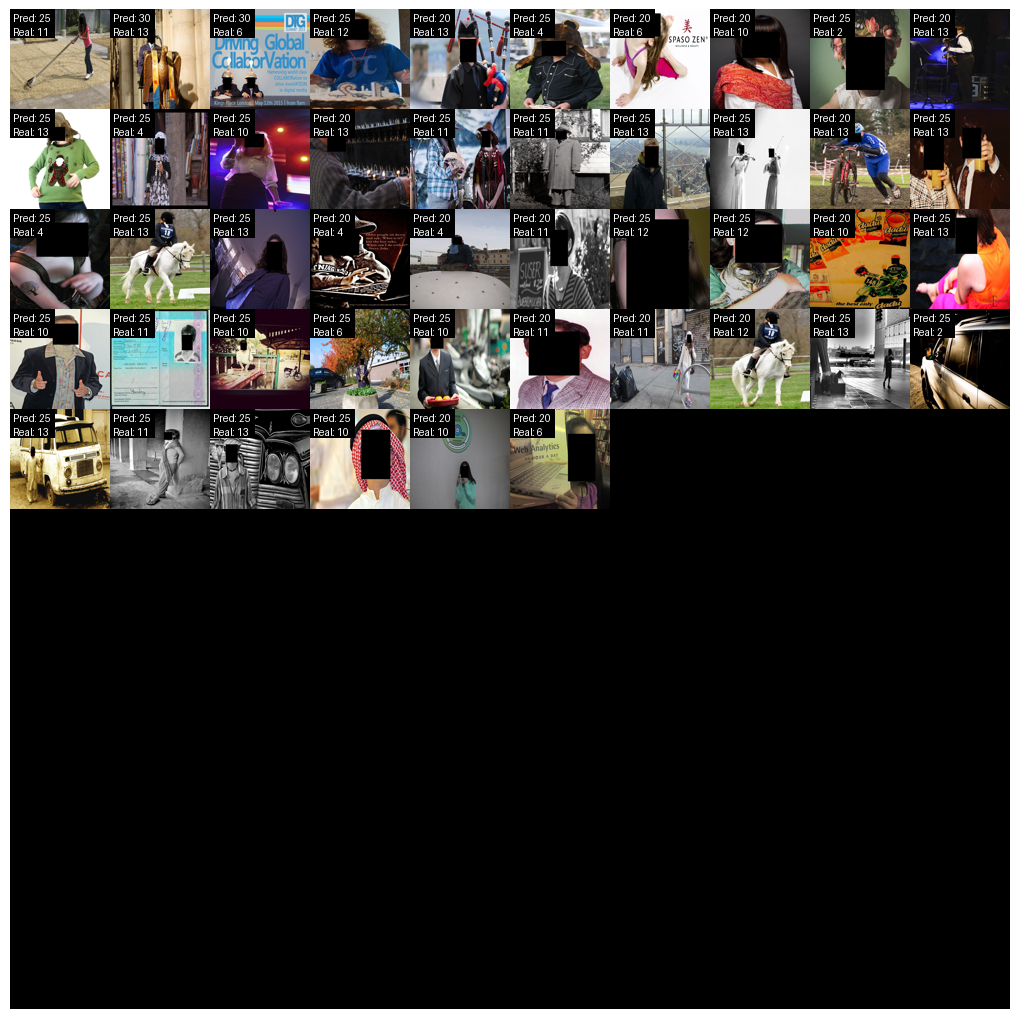

array([[[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [19, 18, 24],
        [19, 18, 23],
        [16, 16, 17]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [19, 18, 25],
        [19, 18, 22],
        [16, 16, 16]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [19, 18, 24],
        [19, 18, 22],
        [16, 16, 16]],

       ...,

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]]], dtype=uint8)
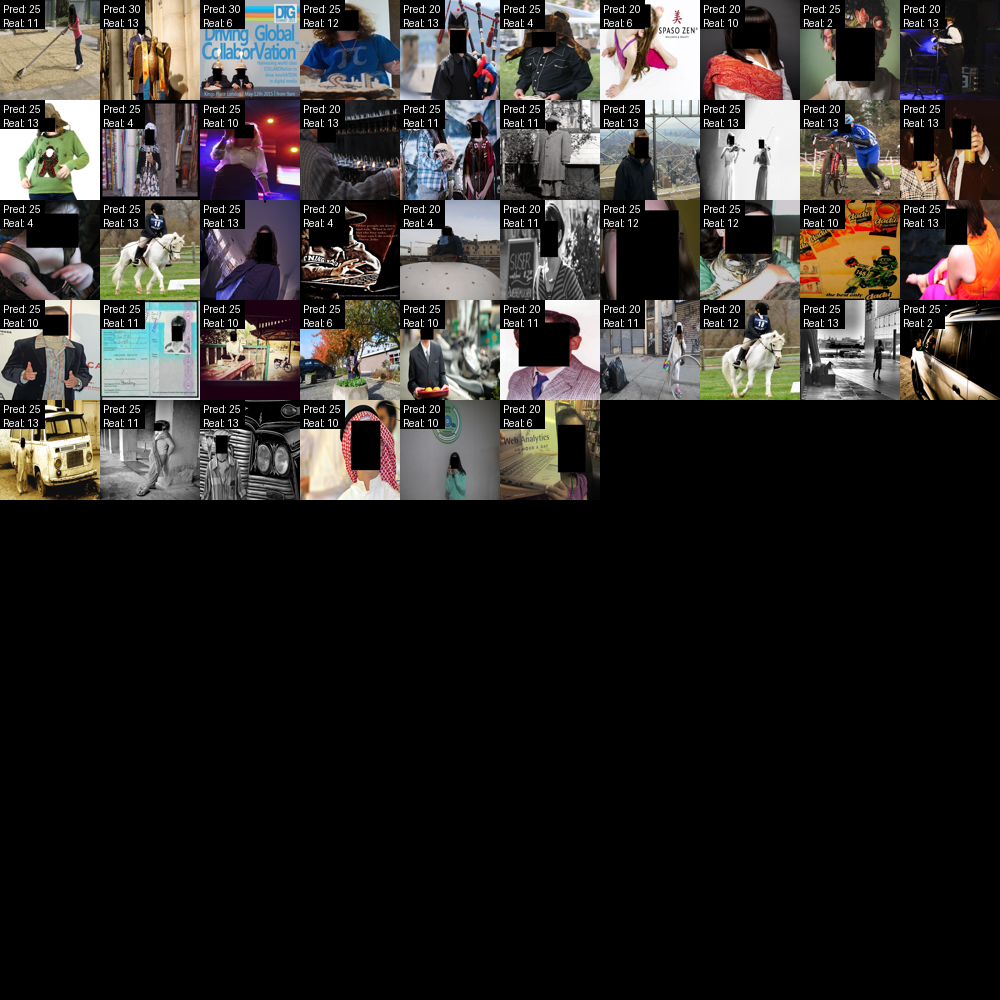

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from io import BytesIO

def plot_mosaic_errors_tight(df_pred, df_real, task_col, threshold=10, n=100, grid_shape=(10, 10), img_size=(100, 100)):
    """
    Plota mosaico tight (sem espaços) com os primeiros `n` erros do modelo.
    Escreve predição e erro sobre a imagem com fundo para visibilidade.
    """
    # Combinar dataframes
    # merged = df_pred.merge(df_real, on=df_pred.columns[0], suffixes=('_pred', '_real'))
    merged = df_pred[df_pred['real_prompt4'] < 14]
    # merged = df_pred
    caminho_col = df_pred.columns[0]
    col_pred = f"pred_prompt4"
    col_real = f"real_prompt4"

    # Filtrar erros com limiar
    erros = merged[merged[col_pred] > 18] #merged[abs(merged[col_pred] - merged[col_real]) > threshold]
    print(f"Total de erros na tarefa '{task_col}': {len(erros)}")
    display(erros)
    # Limitar aos primeiros n
    erros = erros.head(n)
    n_erros = len(erros)

    if n_erros == 0:
        print("Nenhum erro encontrado!")
        return

    # Calcular dimensões do mosaico
    n_rows, n_cols = grid_shape
    img_height, img_width = img_size

    # Criar canvas grande para o mosaico (tight)
    mosaic = np.zeros((n_rows * img_height, n_cols * img_width, 3), dtype=np.uint8)

    # Preencher mosaico
    for idx in range(n_erros):
        row = idx // n_cols
        col = idx % n_cols

        # Carregar imagem
        img_path = erros.iloc[idx][caminho_col]
        try:
            img = Image.open(img_path).resize(img_size)
            img_array = np.array(img)

            # Converter para RGB se necessário
            if len(img_array.shape) == 2:  # Escala de cinza
                img_array = np.stack([img_array] * 3, axis=-1)
            elif img_array.shape[2] == 4:  # RGBA
                img_array = img_array[:, :, :3]

        except Exception as e:
            # Criar imagem cinza para erro
            img_array = np.ones((img_height, img_width, 3), dtype=np.uint8) * 128

        # Adicionar texto com fundo usando PIL (mais confiável que matplotlib)
        img_pil = Image.fromarray(img_array)
        from PIL import ImageDraw, ImageFont

        draw = ImageDraw.Draw(img_pil)

        # Preparar texto da anotação
        pred_val = erros.iloc[idx][col_pred]
        real_val = erros.iloc[idx][col_real]
        error_val = abs(pred_val - real_val)

        # Formatar valores (ajuste conforme necessário)
        if isinstance(pred_val, float):
            annotation = f"Pred: {pred_val:.2f}\nReal: {real_val:.2f}"
        else:
            annotation = f"Pred: {pred_val}\nReal: {real_val}"

        # Configurar fonte (usar fonte padrão)
        try:
            font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 10)
        except:
            font = ImageFont.load_default()

        # Calcular tamanho do texto e desenhar fundo
        bbox = draw.textbbox((0, 0), annotation, font=font)
        text_width = bbox[2] - bbox[0]
        text_height = bbox[3] - bbox[1]

        # Desenhar retângulo de fundo
        padding = 3
        draw.rectangle([(0, 0), (text_width + padding*2, text_height + padding*2)],
                       fill=(0, 0, 0, 180))

        # Desenhar texto
        draw.text((padding, padding), annotation, fill=(255, 255, 255), font=font)

        # Converter de volta para numpy array
        img_array_with_text = np.array(img_pil)

        # Garantir que a imagem tem o tamanho correto
        if img_array_with_text.shape[:2] != (img_height, img_width):
            img_array_with_text = np.array(Image.fromarray(img_array_with_text).resize(img_size))

        # Inserir imagem no mosaico
        y_start = row * img_height
        y_end = y_start + img_height
        x_start = col * img_width
        x_end = x_start + img_width
        mosaic[y_start:y_end, x_start:x_end] = img_array_with_text

    # Exibir mosaico final
    plt.figure(figsize=(n_cols * (img_width/100), n_rows * (img_height/100)), dpi=100)
    plt.imshow(mosaic)
    plt.axis('off')
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
    plt.show()

    return mosaic

plot_mosaic_errors_tight(resultadosLlava, resultadosLlava, 'min_age')

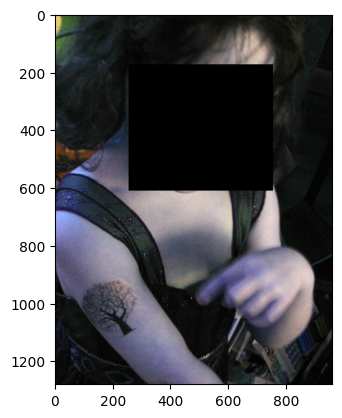

In [ ]:
import cv2
img = cv2.imread('images_noface/7fdb6db380c42250.jpg')
plt.imshow(img)

In [ ]:
!gdown 1mNYjYFb3MuKg-OL1UISoYsKObMUllbJx

Downloading...
From: https://drive.google.com/uc?id=1mNYjYFb3MuKg-OL1UISoYsKObMUllbJx
To: /content/lagenda_annotation.csv
100% 24.8M/24.8M [00:00<00:00, 73.1MB/s]


In [ ]:
original = pd.read_csv('lagenda_annotation.csv')
original[original['img_name'].str.contains('7fdb6db380c42250.jpg')]

,img_name,age,gender,face_x0,face_y0,face_x1,face_y1,person_x0,person_y0,person_x1,person_y1
205773,lag_benchmark/7fdb6db380c42250.jpg,4,F,254,174,752,610,4,0,920,1280
